# DeepFake Audio Detection with ASVSpoof2021 Dataset

## Key Modifications Made:

1. **Dataset Integration**: Modified to work with ASVSpoof2021 DF evaluation dataset
   - Reads metadata from `trial_metadata.txt` to identify real ('bonafide') vs fake ('spoof') audio
   - Works with `.flac` audio files instead of `.wav`/.mp3`
   - Parses ASVSpoof metadata format correctly

2. **Data Sampling**: Limited training data to exactly **20,000 real + 20,000 fake** audio files
   - Randomly samples from available files for balanced training
   - Uses stratified train/test split (80/20) for evaluation

3. **File Path Updates**: 
   - Metadata: `e:\Research Hub\DeepFake Audio Dataset\DF-keys-full\keys\DF\CM\trial_metadata.txt`
   - Audio files: `e:\Research Hub\DeepFake Audio Dataset\ASVspoof2021_DF_eval\flac\`

4. **Code Fixes**:
   - Removed duplicate code line
   - Added proper imports for sklearn functions
   - Updated test data loading to use train/test split instead of separate directories
   - Fixed attention visualization for new data structure

## Usage:
Run cells sequentially. The model will train on exactly 40,000 files (20k real + 20k fake) and evaluate on a held-out test set.

In [2]:
import torch
print(torch.cuda.is_available())  # Should print True if CUDA is available
print(torch.cuda.current_device())  # Should print the current GPU device ID
print(torch.cuda.get_device_name(0))  # Should print the GPU name

True
0
NVIDIA GeForce RTX 4060


In [3]:
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# Try to use soundfile backend which is more robust
try:
    torchaudio.set_audio_backend("soundfile")
except:
    torchaudio.set_audio_backend("sox_io")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalize waveform function
class NormalizeWaveform:
    def __init__(self):
        pass
    
    def __call__(self, waveform):
        return waveform / torch.max(torch.abs(waveform))

# Define custom Dataset class
class AudioDataset(Dataset):
    def __init__(self, audio_paths, labels, transform=None, sample_rate=16000, max_length=160000):
        self.audio_paths = audio_paths
        self.labels = labels
        self.transform = transform
        self.sample_rate = sample_rate
        self.max_length = max_length  # Max length for padding/trimming
    
    def __len__(self):
        return len(self.audio_paths)
    
    def __getitem__(self, idx):
        try:
            # Load audio file
            waveform, sample_rate = torchaudio.load(self.audio_paths[idx])
        except Exception as e:
            print(f"Error loading {self.audio_paths[idx]}: {e}")
            # Return a zero tensor with the expected shape as fallback
            waveform = torch.zeros(1, self.max_length)
            sample_rate = self.sample_rate
        
        # Convert to mono if stereo (fix for channel mismatch error)
        if waveform.size(0) > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
        
        # Resample to a fixed sample rate (if required)
        if sample_rate != self.sample_rate:
            resample_transform = T.Resample(orig_freq=sample_rate, new_freq=self.sample_rate)
            waveform = resample_transform(waveform)
        
        # Padding or trimming waveform to max_length
        if waveform.size(1) < self.max_length:
            padding = self.max_length - waveform.size(1)
            waveform = torch.nn.functional.pad(waveform, (0, padding))
        else:
            waveform = waveform[:, :self.max_length]
        
        # Apply additional transform (normalization)
        if self.transform:
            waveform = self.transform(waveform)
        
        # Get the label for this sample
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return waveform, label

# Load ASVSpoof2021 DF evaluation data
def load_asvspoof_data(metadata_path, audio_dir, max_real=20000, max_fake=20000):
    """
    Load ASVSpoof2021 data with limited number of real and fake samples
    """
    # Read metadata file
    print("Reading metadata file...")
    metadata = []
    with open(metadata_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 6:
                # Format: speaker_id file_id compression source system_id key trim eval_condition primary_tag task team gender user_comment
                file_id = parts[1]
                label = parts[5]  # 'bonafide' or 'spoof'
                metadata.append((file_id, label))
    
    print(f"Total metadata entries: {len(metadata)}")
    
    # Separate real and fake files
    real_files = []
    fake_files = []
    
    for file_id, label in metadata:
        audio_path = os.path.join(audio_dir, f"{file_id}.flac")
        if os.path.exists(audio_path):
            if label == 'bonafide':
                real_files.append(audio_path)
            elif label == 'spoof':
                fake_files.append(audio_path)
    
    print(f"Found {len(real_files)} real files and {len(fake_files)} fake files")
    
    # Randomly sample the specified number of files
    random.seed(42)  # For reproducibility
    if len(real_files) > max_real:
        real_files = random.sample(real_files, max_real)
    if len(fake_files) > max_fake:
        fake_files = random.sample(fake_files, max_fake)
    
    print(f"Selected {len(real_files)} real files and {len(fake_files)} fake files")
    
    # Combine and create labels
    audio_paths = real_files + fake_files
    labels = [0] * len(real_files) + [1] * len(fake_files)  # 0 for real, 1 for fake
    
    return audio_paths, labels

# Load training data from ASVSpoof dataset
metadata_path = r'e:/Research Hub/DeepFake Audio Dataset/DF-keys-full/keys/DF/CM/trial_metadata.txt'
audio_dir = r'e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac'

print("Loading ASVSpoof2021 data...")
train_audio_paths, train_labels = load_asvspoof_data(metadata_path, audio_dir, max_real=20000, max_fake=20000)

# Verify total number of files
print(f"Total number of files: {len(train_audio_paths)}")
print(f"Real files: {train_labels.count(0)}, Fake files: {train_labels.count(1)}")

# Add normalization step in DataLoader
transform = NormalizeWaveform()  # Normalize the waveforms to [-1, 1]

# Create DataLoader with padding/trimming and normalization
train_dataset = AudioDataset(train_audio_paths, train_labels, transform=transform, sample_rate=16000, max_length=160000)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Check the first batch (optional, just for verification)
for waveform, label in train_loader:
    print(waveform.shape, label)  # Should print tensor size and the labels (0 for real, 1 for fake)
    break

# Print the total number of batches in the DataLoader
print(f'Total number of batches: {len(train_loader)}')

C:\Users\User\AppData\Local\Temp\ipykernel_22096\1322510980.py:12: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")


Loading ASVSpoof2021 data...
Reading metadata file...
Total metadata entries: 611829
Total metadata entries: 611829
Found 22617 real files and 589212 fake files
Selected 20000 real files and 20000 fake files
Total number of files: 40000
Real files: 20000, Fake files: 20000
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2978280.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2574721.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4381336.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2245709.flac: Error : flac decoder lost sync.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4686832.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF

Original Min: -0.81903076171875
Original Max: 0.999969482421875
Normalized Min: -0.8190557360649109
Normalized Max: 1.0


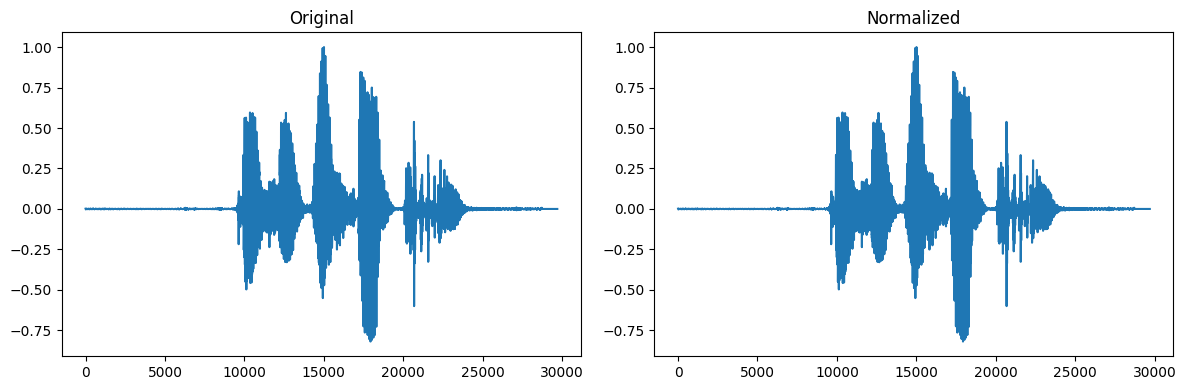

In [4]:
# Check min and max before and after normalization for a random file
if len(train_audio_paths) > 0:
    audio_path = train_audio_paths[100]  # Use the 100th audio file for testing
    waveform, sample_rate = torchaudio.load(audio_path)

    print("Original Min:", waveform.min().item())
    print("Original Max:", waveform.max().item())

    # Normalize the waveform
    normalized_waveform = transform(waveform)

    # Check min and max after normalization
    print("Normalized Min:", normalized_waveform.min().item())
    print("Normalized Max:", normalized_waveform.max().item())

    # Plotting the original and normalized waveforms (for verification)
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Plot original waveform
    axs[0].plot(waveform.t().numpy())
    axs[0].set_title('Original')

    # Plot normalized waveform
    axs[1].plot(normalized_waveform.t().numpy())
    axs[1].set_title('Normalized')

    # Display the plot
    plt.tight_layout()
    plt.show()
else:
    print("No audio files loaded for normalization check")

In [5]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
import torch

# Initialize Wav2Vec2 Processor and Model
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
model = Wav2Vec2ForSequenceClassification.from_pretrained("facebook/wav2vec2-base", num_labels=2)
model.to(device)

# Feature extraction function (for handling batches)
def extract_features(waveforms):
    # Check if the waveform has 3 or more dimensions and squeeze the unnecessary ones
    # If we have shape [batch_size, 1, sequence_length], we want to squeeze the channel dimension
    if len(waveforms.shape) == 3:
        waveforms = waveforms.squeeze(1)  # Remove the second dimension if it's 1
    
    # Convert waveforms to numpy for processor
    waveforms_numpy = waveforms.cpu().numpy()
    
    # Process the waveforms using Wav2Vec2
    inputs = processor(waveforms_numpy, sampling_rate=16000, return_tensors="pt", padding=True)
    inputs = inputs.to(device)
    
    with torch.no_grad():
        # Extract features from the Wav2Vec2 model
        outputs = model.wav2vec2(inputs.input_values).last_hidden_state
    
    return outputs

e:\Research Hub\DeepFake Audio Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 5065.58it/s]

e:\Research Hub\DeepFake Audio Dataset\.venv\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
e:\Research Hub\DeepFake Audio Dataset\.venv\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkp

In [7]:
import numpy as np
import torch
from tqdm import tqdm
import os

# Create folder for storing extracted features
features_dir = "extracted_features"
if not os.path.exists(features_dir):
    os.makedirs(features_dir)
    print(f"Created directory: {features_dir}")

def save_extracted_features_chunked(train_loader, chunk_size=500):
    """
    Extract and save features in chunks to manage memory efficiently
    """
    # Check if extract_features function is available
    if 'extract_features' not in globals():
        print("Error: extract_features function not found. Please run cell 5 first.")
        return
    
    chunk_features = []
    chunk_labels = []
    chunk_count = 0
    
    try:
        with torch.no_grad():
            for batch_idx, (waveforms, labels) in enumerate(tqdm(train_loader, desc="Extracting features")):
                waveforms = waveforms.to(device)
                features = extract_features(waveforms)
                chunk_features.append(features.cpu())
                chunk_labels.extend(labels.numpy())
                
                # Save chunk when reaching chunk_size samples
                if len(chunk_labels) >= chunk_size:
                    chunk_count += 1
                    
                    # Save to the features directory
                    features_path = os.path.join(features_dir, f"features_chunk_{chunk_count}.pt")
                    labels_path = os.path.join(features_dir, f"labels_chunk_{chunk_count}.npy")
                    
                    torch.save(torch.cat(chunk_features, dim=0), features_path)
                    np.save(labels_path, np.array(chunk_labels))
                    print(f"Saved chunk {chunk_count} with {len(chunk_labels)} samples")
                    
                    # Clear memory
                    chunk_features = []
                    chunk_labels = []
                    torch.cuda.empty_cache()
                
                # Regular memory cleanup
                if (batch_idx + 1) % 50 == 0:
                    torch.cuda.empty_cache()
        
        # Save remaining samples
        if chunk_features:
            chunk_count += 1
            features_path = os.path.join(features_dir, f"features_chunk_{chunk_count}.pt")
            labels_path = os.path.join(features_dir, f"labels_chunk_{chunk_count}.npy")
            
            torch.save(torch.cat(chunk_features, dim=0), features_path)
            np.save(labels_path, np.array(chunk_labels))
            print(f"Saved final chunk {chunk_count}")
        
        print(f"Feature extraction complete! Saved {chunk_count} chunks in '{features_dir}' folder.")
        
    except Exception as e:
        print(f"Error during feature extraction: {e}")
        print("Make sure Wav2Vec2 models are loaded (run cell 5 first)")

# Run chunked extraction (only if extract_features function exists)
if 'extract_features' in globals() and 'train_loader' in globals():
    save_extracted_features_chunked(train_loader, chunk_size=2000)
else:
    print("Skipping feature extraction - please run previous cells first (data loading and Wav2Vec2 setup)")
    print("Available variables:")
    if 'train_loader' not in globals():
        print("  - train_loader: NOT AVAILABLE (run cell 3)")
    else:
        print("  - train_loader: ✓ Available")
    if 'extract_features' not in globals():
        print("  - extract_features: NOT AVAILABLE (run cell 5)")
    else:
        print("  - extract_features: ✓ Available")

Extracting features:   0%|          | 0/2500 [00:00<?, ?it/s]

Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2323973.flac: Error : flac decoder lost sync.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4490789.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3174177.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2548294.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4883849.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2882931.flac: Error : flac decoder lost sync.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2398431.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021

Extracting features:   0%|          | 1/2500 [00:00<28:25,  1.47it/s]

Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4966354.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3465410.flac: Error : flac decoder lost sync.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2055256.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3045108.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4847167.flac: Internal psf_fseek() failed.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3496131.flac: Error : flac decoder lost sync.


Extracting features:   0%|          | 2/2500 [00:01<21:25,  1.94it/s]

...

Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4809369.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2662090.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2413083.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3966015.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3578964.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2050860.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3891545.flac: Error : unknown error in flac decoder.


Extracting features: 100%|█████████▉| 2499/2500 [18:28<00:00,  2.52it/s]

Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3687452.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3556777.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2195740.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2376873.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_4463002.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_2239654.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Audio Dataset/ASVspoof2021_DF_eval/flac\DF_E_3539707.flac: Error : unknown error in flac decoder.
Error loading e:/Research Hub/DeepFake Au

Extracting features: 100%|██████████| 2500/2500 [18:35<00:00,  2.24it/s]

Saved chunk 20 with 2000 samples
Feature extraction complete! Saved 20 chunks in 'extracted_features' folder.


In [6]:
import torch.nn as nn

# DeepFakeLSTM Model Definition (with self-attention) - FIXED VERSION
class DeepFakeLSTM(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_layers=2, num_classes=2):
        super(DeepFakeLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Bidirectional LSTM with reduced dropout
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, bidirectional=True, dropout=0.2)
        
        # Self-Attention Mechanism with proper initialization
        self.attention = nn.Linear(hidden_dim * 2, 1)
        
        # Classification layers with batch normalization
        self.dropout = nn.Dropout(0.3)  # Reduced dropout
        self.bn1 = nn.BatchNorm1d(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        
        # Initialize weights properly
        self._init_weights()

    def _init_weights(self):
        """Initialize weights to prevent gradient issues"""
        for name, param in self.named_parameters():
            if 'weight' in name and param.dim() >= 2:  # Only for weight matrices
                if 'lstm' in name:
                    nn.init.orthogonal_(param.data)
                else:
                    nn.init.xavier_uniform_(param.data)
            elif 'bias' in name:
                nn.init.constant_(param.data, 0)

    def attention_layer(self, lstm_out):
        # Compute attention scores with numerical stability
        scores = self.attention(lstm_out)  # Shape: [batch_size, seq_len, 1]
        # Add small epsilon for numerical stability
        scores = torch.clamp(scores, min=-10, max=10)
        attn_weights = torch.softmax(scores, dim=1)  # Softmax to get attention weights

        # Compute weighted sum of LSTM outputs (apply attention weights)
        weighted_sum = torch.sum(lstm_out * attn_weights, dim=1)  # Shape: [batch_size, hidden_dim]
        return weighted_sum
    
    def forward(self, x):
        # Check for NaN/Inf in input
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("WARNING: NaN/Inf detected in input!")
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # LSTM layer
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Self-Attention Mechanism
        attn_out = self.attention_layer(lstm_out)  # Shape: [batch_size, hidden_dim * 2]
        
        # Classification with batch normalization
        x = self.bn1(attn_out)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.bn2(x)
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.bn3(x)
        x = self.dropout(x)
        x = self.fc3(x)
        
        # Check for NaN/Inf in output
        if torch.isnan(x).any() or torch.isinf(x).any():
            print("WARNING: NaN/Inf detected in output!")
            x = torch.nan_to_num(x, nan=0.0, posinf=1.0, neginf=-1.0)
        
        return x

# Initialize DeepFakeLSTM model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lstm_model = DeepFakeLSTM().to(device)

print("✅ Fixed DeepFakeLSTM model initialized with:")
print("   - Proper weight initialization")
print("   - Batch normalization")
print("   - Gradient clipping support")
print("   - NaN/Inf detection")
print("   - Reduced dropout rates")

✅ Fixed DeepFakeLSTM model initialized with:
   - Proper weight initialization
   - Batch normalization
   - Gradient clipping support
   - NaN/Inf detection
   - Reduced dropout rates


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import glob
from sklearn.model_selection import train_test_split

# Find all chunk files in the extracted_features folder
features_dir = "extracted_features"
feature_files = sorted(glob.glob(os.path.join(features_dir, "features_chunk_*.pt")))
label_files = sorted(glob.glob(os.path.join(features_dir, "labels_chunk_*.npy")))

print(f"Found {len(feature_files)} feature chunks in '{features_dir}' folder")

# FIXED: Loss Function, Optimizer with lower learning rate
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(lstm_model.parameters(), lr=0.0001, weight_decay=1e-5)  # Much lower LR
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

# Trackers
train_losses = []
train_accuracies = []
val_losses = []  
val_accuracies = []
epochs = 10
final_preds = []
final_labels = []

# Split chunks into train/validation (80/20 split)
chunk_indices = list(range(len(feature_files)))
train_chunks_idx, val_chunks_idx = train_test_split(chunk_indices, test_size=0.2, random_state=42)

print(f"Training chunks: {len(train_chunks_idx)}, Validation chunks: {len(val_chunks_idx)}")

# FIXED Training Loop with Gradient Clipping and NaN Detection
for epoch in range(epochs):
    # TRAINING PHASE
    lstm_model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    epoch_preds = []
    epoch_labels = []
    batch_count = 0
    
    # Process training chunks only
    for chunk_idx in train_chunks_idx:
        feat_file = feature_files[chunk_idx]
        label_file = label_files[chunk_idx]
        # Load one chunk at a time
        chunk_features = torch.load(feat_file)
        chunk_labels = np.load(label_file)
        
        # Check for NaN/Inf in features
        if torch.isnan(chunk_features).any() or torch.isinf(chunk_features).any():
            print(f"WARNING: NaN/Inf found in chunk {chunk_idx}, cleaning...")
            chunk_features = torch.nan_to_num(chunk_features, nan=0.0, posinf=1.0, neginf=-1.0)
        
        # Create DataLoader for this chunk
        class ChunkDataset(Dataset):
            def __init__(self, features, labels):
                self.features = features
                self.labels = torch.tensor(labels).long()
            def __len__(self):
                return len(self.labels)
            def __getitem__(self, idx):
                return self.features[idx], self.labels[idx]
        
        chunk_dataset = ChunkDataset(chunk_features, chunk_labels)
        chunk_loader = DataLoader(chunk_dataset, batch_size=16, shuffle=True)  # Smaller batch size
        
        # Train on this chunk
        for feats, labels in chunk_loader:
            feats = feats.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = lstm_model(feats)
            loss = criterion(outputs, labels)
            
            # Check for NaN loss
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"❌ NaN/Inf loss detected! Skipping batch.")
                continue
            
            # Backward pass with gradient clipping
            optimizer.zero_grad()
            loss.backward()
            
            # CRITICAL: Gradient clipping to prevent explosion
            torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item()
            batch_count += 1
            _, predicted = torch.max(outputs, 1)
            correct_preds += (predicted == labels).sum().item()
            total_preds += labels.size(0)
            
            epoch_preds.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())
        
        # Clear memory after each chunk
        del chunk_features, chunk_labels, chunk_dataset, chunk_loader
        torch.cuda.empty_cache()

    # VALIDATION PHASE
    lstm_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for chunk_idx in val_chunks_idx:
            feat_file = feature_files[chunk_idx]
            label_file = label_files[chunk_idx]
            
            chunk_features = torch.load(feat_file)
            chunk_labels = np.load(label_file)
            
            # Clean validation data too
            if torch.isnan(chunk_features).any() or torch.isinf(chunk_features).any():
                chunk_features = torch.nan_to_num(chunk_features, nan=0.0, posinf=1.0, neginf=-1.0)
            
            chunk_dataset = ChunkDataset(chunk_features, chunk_labels)
            chunk_loader = DataLoader(chunk_dataset, batch_size=16, shuffle=False)
            
            for feats, labels in chunk_loader:
                feats = feats.to(device)
                labels = labels.to(device)
                
                outputs = lstm_model(feats)
                loss = criterion(outputs, labels)
                
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    val_loss += loss.item()
                    val_batch_count += 1
                
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
            
            del chunk_features, chunk_labels, chunk_dataset, chunk_loader
            torch.cuda.empty_cache()

    # Calculate metrics
    val_accuracy = val_correct / val_total if val_total > 0 else 0
    epoch_loss = running_loss / batch_count if batch_count > 0 else float('inf')
    epoch_accuracy = correct_preds / total_preds if total_preds > 0 else 0
    val_loss_avg = val_loss / val_batch_count if val_batch_count > 0 else float('inf')
    
    # Update learning rate
    scheduler.step(val_loss_avg)
    
    val_losses.append(val_loss_avg)
    val_accuracies.append(val_accuracy)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    
    # Enhanced logging
    print(f"Epoch [{epoch+1}/{epochs}]:")
    print(f"  Train Loss: {epoch_loss:.6f}, Train Acc: {epoch_accuracy:.4f}")
    print(f"  Val Loss: {val_loss_avg:.6f}, Val Acc: {val_accuracy:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.2e}")
    
    # Check prediction distribution
    unique_preds, pred_counts = np.unique(epoch_preds, return_counts=True)
    print(f"  Predictions: {dict(zip(unique_preds, pred_counts))}")
    
    if epoch == epochs - 1:
        final_preds = epoch_preds
        final_labels = epoch_labels

print("✅ Training completed with gradient clipping and NaN protection!")

Found 20 feature chunks in 'extracted_features' folder
Training chunks: 16, Validation chunks: 4
Epoch [1/10]:
  Train Loss: 0.675066, Train Acc: 0.6500
  Val Loss: 0.528393, Val Acc: 0.7037
  LR: 1.00e-04
  Predictions: {np.int64(0): np.int64(16541), np.int64(1): np.int64(15459)}
Epoch [1/10]:
  Train Loss: 0.675066, Train Acc: 0.6500
  Val Loss: 0.528393, Val Acc: 0.7037
  LR: 1.00e-04
  Predictions: {np.int64(0): np.int64(16541), np.int64(1): np.int64(15459)}
Epoch [2/10]:
  Train Loss: 0.534486, Train Acc: 0.6995
  Val Loss: 0.445378, Val Acc: 0.7376
  LR: 1.00e-04
  Predictions: {np.int64(0): np.int64(16641), np.int64(1): np.int64(15359)}
Epoch [2/10]:
  Train Loss: 0.534486, Train Acc: 0.6995
  Val Loss: 0.445378, Val Acc: 0.7376
  LR: 1.00e-04
  Predictions: {np.int64(0): np.int64(16641), np.int64(1): np.int64(15359)}
Epoch [3/10]:
  Train Loss: 0.489784, Train Acc: 0.7122
  Val Loss: 0.425983, Val Acc: 0.7456
  LR: 1.00e-04
  Predictions: {np.int64(0): np.int64(17027), np.int64

In [8]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Calculate comprehensive metrics using sklearn
accuracy = accuracy_score(final_labels, final_preds)
precision, recall, f1, _ = precision_recall_fscore_support(final_labels, final_preds, average='binary')

tn, fp, fn, tp = confusion_matrix(final_labels, final_preds).ravel()
specificity = tn / (tn + fp)  # How many actual reals were correctly identified

# Print results from sklearn
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Specificity: {specificity:.4f}")

Accuracy: 0.7594
Precision: 0.7888
Recall: 0.7108
F1-score: 0.7478
Specificity: 0.8084


In [9]:
# This cell to check for data leakage
import numpy as np

# Check label distribution across chunks
print("CHUNK ANALYSIS")
for i, (feat_file, label_file) in enumerate(zip(feature_files[:], label_files[:])):
    labels = np.load(label_file)
    real_count = np.sum(labels == 0)
    fake_count = np.sum(labels == 1)
    print(f"Chunk {i+1}: Real={real_count}, Fake={fake_count}, Ratio={real_count/fake_count:.2f}")

# Check overall distribution
all_labels = []
for label_file in label_files:
    chunk_labels = np.load(label_file)
    all_labels.extend(chunk_labels)

print(f"\nOVERALL DISTRIBUTION")
print(f"Total Real: {all_labels.count(0)}")
print(f"Total Fake: {all_labels.count(1)}")
print(f"Class Balance: {all_labels.count(0)/all_labels.count(1):.2f}")

# Check if model is just predicting majority class
print(f"\nPREDICTION ANALYSIS")
if 'final_preds' in locals():
    unique, counts = np.unique(final_preds, return_counts=True)
    print(f"Predicted classes: {dict(zip(unique, counts))}")

CHUNK ANALYSIS
Chunk 1: Real=1038, Fake=962, Ratio=1.08
Chunk 2: Real=1008, Fake=992, Ratio=1.02
Chunk 3: Real=1035, Fake=965, Ratio=1.07
Chunk 4: Real=957, Fake=1043, Ratio=0.92
Chunk 5: Real=1005, Fake=995, Ratio=1.01
Chunk 6: Real=1002, Fake=998, Ratio=1.00
Chunk 7: Real=1019, Fake=981, Ratio=1.04
Chunk 8: Real=1035, Fake=965, Ratio=1.07
Chunk 9: Real=971, Fake=1029, Ratio=0.94
Chunk 10: Real=938, Fake=1062, Ratio=0.88
Chunk 11: Real=1022, Fake=978, Ratio=1.04
Chunk 12: Real=996, Fake=1004, Ratio=0.99
Chunk 13: Real=985, Fake=1015, Ratio=0.97
Chunk 14: Real=1002, Fake=998, Ratio=1.00
Chunk 15: Real=1024, Fake=976, Ratio=1.05
Chunk 16: Real=1032, Fake=968, Ratio=1.07
Chunk 17: Real=954, Fake=1046, Ratio=0.91
Chunk 18: Real=977, Fake=1023, Ratio=0.96
Chunk 19: Real=988, Fake=1012, Ratio=0.98
Chunk 20: Real=1012, Fake=988, Ratio=1.02

OVERALL DISTRIBUTION
Total Real: 20000
Total Fake: 20000
Class Balance: 1.00

PREDICTION ANALYSIS
Predicted classes: {np.int64(0): np.int64(17533), np.in

Final Training Accuracy: 75.94%
Final Validation Accuracy: 76.74%
Final Training Loss: 0.3940
Final Validation Loss: 0.3739


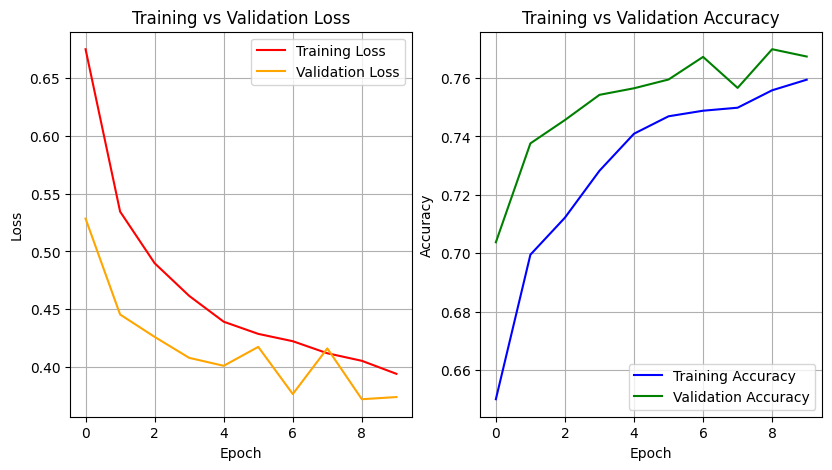

In [10]:
import matplotlib.pyplot as plt

# Plotting the Training and Validation Loss and Accuracy after training
plt.figure(figsize=(15, 5))

# Plot Training and Validation Loss
plt.subplot(1, 3, 1)
plt.plot(train_losses, color='red', label='Training Loss')
plt.plot(val_losses, color='orange', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Training and Validation Accuracy
plt.subplot(1, 3, 2)
plt.plot(train_accuracies, color='blue', label='Training Accuracy')
plt.plot(val_accuracies, color='green', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Print final metrics
print(f"Final Training Accuracy: {train_accuracies[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]*100:.2f}%")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

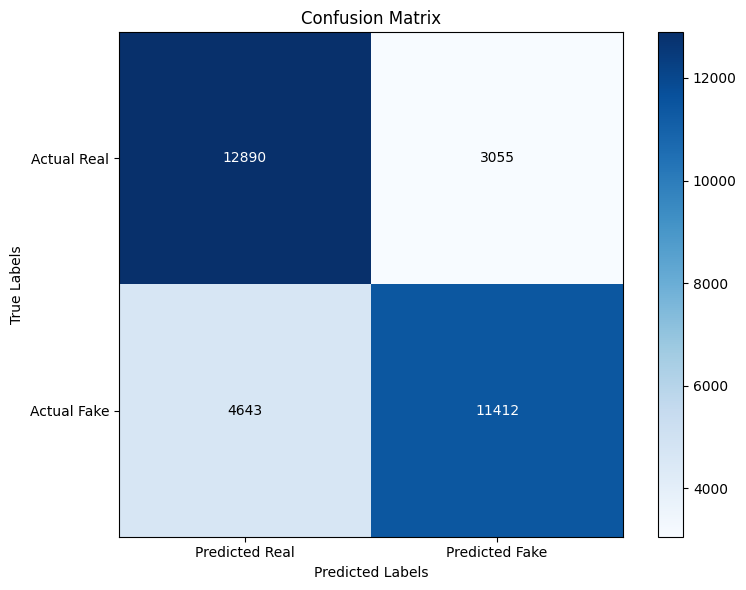

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Compute confusion matrix using final labels and predictions
conf_matrix = confusion_matrix(final_labels, final_preds)

# Create the heatmap using matplotlib
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Add color bar
plt.colorbar()

# Annotating each cell with the numeric value
thresh = conf_matrix.max() / 2
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        plt.text(j, i, format(conf_matrix[i, j], 'g'),
                 ha="center", va="center", color="white" if conf_matrix[i, j] > thresh else "black")

# Set tick marks and labels
plt.xticks(np.arange(conf_matrix.shape[1]), ['Predicted Real', 'Predicted Fake'])
plt.yticks(np.arange(conf_matrix.shape[0]), ['Actual Real', 'Actual Fake'])

# Display the plot
plt.tight_layout()
plt.show()

Using validation chunks for ROC: 4 chunks


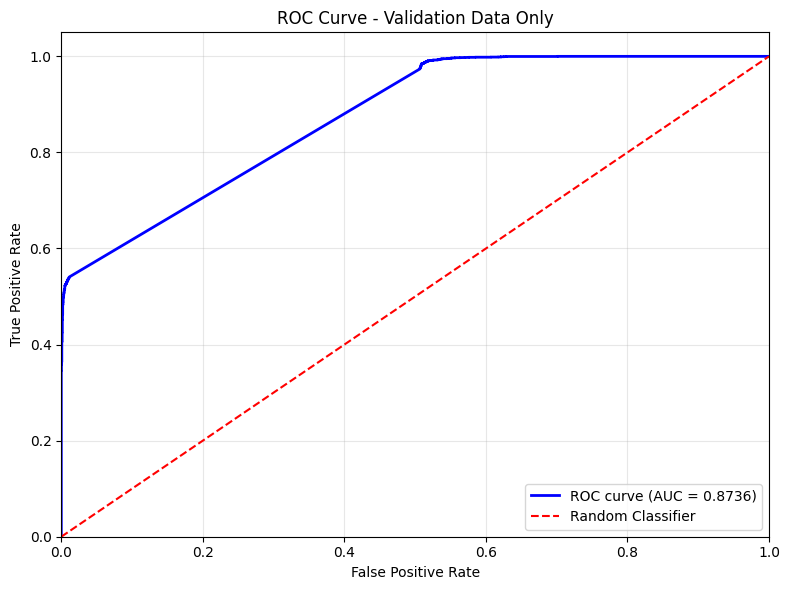

Validation AUC Score: 0.8736

Prediction distribution:
Min probability: 0.0014
Max probability: 0.9991
Mean probability: 0.4754
Std probability: 0.3561

Validation EER: 0.0116 (1.16%)
EER Threshold: 0.4395


In [13]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import glob

# Get all chunk files from the extracted_features folder
features_dir = "extracted_features"
feature_files = sorted(glob.glob(os.path.join(features_dir, "features_chunk_*.pt")))
label_files = sorted(glob.glob(os.path.join(features_dir, "labels_chunk_*.npy")))

# Use the SAME validation split as your training
from sklearn.model_selection import train_test_split
chunk_indices = list(range(len(feature_files)))
train_chunks_idx, val_chunks_idx = train_test_split(chunk_indices, test_size=0.2, random_state=42)

print(f"Using validation chunks for ROC: {len(val_chunks_idx)} chunks")

# Memory-efficient ROC curve generation - ONLY on validation chunks
lstm_model.eval()
predicted_probs = []
true_labels = []

batch_size = 32

with torch.no_grad():
    # Process ONLY validation chunks
    for chunk_idx in val_chunks_idx:
        feat_file = feature_files[chunk_idx]
        label_file = label_files[chunk_idx]
        
        # Load one chunk at a time
        chunk_features = torch.load(feat_file)
        chunk_labels = np.load(label_file)
        
        # Move features to device
        chunk_features = chunk_features.to(device)
        
        # Process this chunk in batches
        for i in range(0, len(chunk_features), batch_size):
            batch_features = chunk_features[i:i+batch_size]
            batch_labels = chunk_labels[i:i+batch_size]
            
            outputs = lstm_model(batch_features)
            prob = torch.softmax(outputs, dim=1)
            
            # Store results
            predicted_probs.extend(prob.cpu().numpy())
            true_labels.extend(batch_labels)
        
        # Clear memory after each chunk
        del chunk_features, chunk_labels
        torch.cuda.empty_cache()

# Convert to numpy arrays
predicted_probs = np.array(predicted_probs)
true_labels = np.array(true_labels)

# Generate ROC curve
fpr, tpr, thresholds = roc_curve(true_labels, predicted_probs[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Data Only')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Validation AUC Score: {roc_auc:.4f}")

# Additional diagnostic information
print(f"\nPrediction distribution:")
print(f"Min probability: {predicted_probs[:, 1].min():.4f}")
print(f"Max probability: {predicted_probs[:, 1].max():.4f}")
print(f"Mean probability: {predicted_probs[:, 1].mean():.4f}")
print(f"Std probability: {predicted_probs[:, 1].std():.4f}")

# Add this to Cell 11 after your existing ROC calculation
# ...existing ROC code...

# ===== CALCULATE EER FROM EXISTING ROC DATA =====
# You already have: fpr, tpr, thresholds from your ROC curve
fnr = 1 - tpr  # False Negative Rate = 1 - True Positive Rate

# Find EER point where FPR ≈ FNR
eer_idx = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_idx]
eer_threshold = thresholds[eer_idx]

print(f"\nValidation EER: {eer:.4f} ({eer*100:.2f}%)")
print(f"EER Threshold: {eer_threshold:.4f}")

In [ ]:
from sklearn.model_selection import KFold
import torch.optim as optim
import torch.nn as nn
import torch
import glob
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from torch.utils.data import Dataset, DataLoader

# Get all your chunk files from the extracted_features folder
features_dir = "extracted_features"
feature_files = sorted(glob.glob(os.path.join(features_dir, "features_chunk_*.pt")))  # All chunks
label_files = sorted(glob.glob(os.path.join(features_dir, "labels_chunk_*.npy")))     # All chunks

print(f"Found {len(feature_files)} feature chunks and {len(label_files)} label chunks in '{features_dir}' folder")

# Define ChunkDataset class (needed for cross-validation)
class ChunkDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = torch.tensor(labels).long()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Cross-validation parameters
k = 5
epochs = 10

# Lists to store metrics across all folds
fold_accuracies = []
fold_losses = []

# Create indices for chunk-level splitting
chunk_indices = list(range(len(feature_files)))
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Cross-validation loop
for fold, (train_chunks_idx, val_chunks_idx) in enumerate(kf.split(chunk_indices)):
    print(f"\nFOLD {fold + 1}/{k}")
    print(f"Training chunks: {len(train_chunks_idx)}, Validation chunks: {len(val_chunks_idx)}")
    
    # Initialize fresh model for each fold
    lstm_model = DeepFakeLSTM().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(lstm_model.parameters(), lr=0.0001, weight_decay=1e-5)  # Match cell 8 settings
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    
    # Training phase
    for epoch in range(epochs):
        lstm_model.train()
        running_loss = 0.0
        correct_preds = 0
        total_preds = 0
        batch_count = 0
        
        # Process training chunks
        for chunk_idx in train_chunks_idx:
            # Load chunk data
            chunk_features = torch.load(feature_files[chunk_idx])
            chunk_labels = np.load(label_files[chunk_idx])
            
            # IMPORTANT: Clean NaN/Inf values (same as cell 8)
            if torch.isnan(chunk_features).any() or torch.isinf(chunk_features).any():
                print(f"WARNING: NaN/Inf found in chunk {chunk_idx}, cleaning...")
                chunk_features = torch.nan_to_num(chunk_features, nan=0.0, posinf=1.0, neginf=-1.0)
            
            # Create mini-batches from this chunk
            chunk_dataset = ChunkDataset(chunk_features, chunk_labels)
            chunk_loader = DataLoader(chunk_dataset, batch_size=16, shuffle=True)  # Match cell 8 batch size
            
            # Train on this chunk
            for feats, labels in chunk_loader:
                feats = feats.to(device)
                labels = labels.to(device)
                
                outputs = lstm_model(feats)
                loss = criterion(outputs, labels)
                
                # Check for NaN loss (same as cell 8)
                if torch.isnan(loss) or torch.isinf(loss):
                    print(f"❌ NaN/Inf loss detected! Skipping batch.")
                    continue
                
                optimizer.zero_grad()
                loss.backward()
                
                # CRITICAL: Add gradient clipping (same as cell 8)
                torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
                
                optimizer.step()
                
                running_loss += loss.item()
                batch_count += 1
                _, predicted = torch.max(outputs, 1)
                correct_preds += (predicted == labels).sum().item()
                total_preds += labels.size(0)
            
            # Memory cleanup
            del chunk_features, chunk_labels, chunk_dataset, chunk_loader
            torch.cuda.empty_cache()
        
        # FIXED: Correct loss calculation
        epoch_loss = running_loss / batch_count if batch_count > 0 else float('inf')
        epoch_accuracy = correct_preds / total_preds if total_preds > 0 else 0
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")
    
    # Validation phase
    lstm_model.eval()
    val_preds = []
    val_labels = []
    val_loss = 0.0
    val_batch_count = 0
    
    with torch.no_grad():
        for chunk_idx in val_chunks_idx:
            # Load validation chunk
            chunk_features = torch.load(feature_files[chunk_idx])
            chunk_labels = np.load(label_files[chunk_idx])
            
            # Clean validation data too
            if torch.isnan(chunk_features).any() or torch.isinf(chunk_features).any():
                chunk_features = torch.nan_to_num(chunk_features, nan=0.0, posinf=1.0, neginf=-1.0)
            
            chunk_dataset = ChunkDataset(chunk_features, chunk_labels)
            chunk_loader = DataLoader(chunk_dataset, batch_size=16, shuffle=False)
            
            # Evaluate on this chunk
            for feats, labels in chunk_loader:
                feats = feats.to(device)
                labels = labels.to(device)
                
                outputs = lstm_model(feats)
                loss = criterion(outputs, labels)
                
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    val_loss += loss.item()
                    val_batch_count += 1
                
                _, predicted = torch.max(outputs, 1)
                val_preds.extend(predicted.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
            
            # Memory cleanup
            del chunk_features, chunk_labels, chunk_dataset, chunk_loader
            torch.cuda.empty_cache()
    
    # Calculate fold metrics
    fold_accuracy = accuracy_score(val_labels, val_preds)
    fold_accuracies.append(fold_accuracy)
    fold_loss_avg = val_loss / val_batch_count if val_batch_count > 0 else float('inf')
    fold_losses.append(fold_loss_avg)
    
    # Update learning rate
    scheduler.step(fold_loss_avg)
    
    print(f"Fold {fold + 1} Validation Accuracy: {fold_accuracy:.4f}")
    print(f"Fold {fold + 1} Validation Loss: {fold_loss_avg:.4f}")

# Final results
print(f"\nCROSS-VALIDATION RESULTS")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Average Loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}")
print(f"Individual fold accuracies: {[f'{acc:.4f}' for acc in fold_accuracies]}")
print(f"Individual fold losses: {[f'{loss:.4f}' for loss in fold_losses]}")

In [ ]:
# For testing, we'll use a subset of the loaded data (split from training data)
# Since ASVSpoof2021 DF evaluation set is designed for evaluation, we'll create a train/test split

from sklearn.model_selection import train_test_split

# Split the data into train and test sets (80% train, 20% test)
train_paths, test_paths, train_labels_split, test_labels_split = train_test_split(
    train_audio_paths, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

# Update training data to use only the training split
train_audio_paths = train_paths
train_labels = train_labels_split

# Set up test data
test_audio_paths = test_paths
test_labels = test_labels_split

# Verify the splits
print(f"Training set: {len(train_audio_paths)} files")
print(f"  - Real: {train_labels.count(0)}, Fake: {train_labels.count(1)}")
print(f"Test set: {len(test_audio_paths)} files")
print(f"  - Real: {test_labels.count(0)}, Fake: {test_labels.count(1)}")

# Create DataLoader for the test data
test_dataset = AudioDataset(test_audio_paths, test_labels, transform=transform, sample_rate=16000, max_length=160000)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Update the training dataset and loader with the new split
train_dataset = AudioDataset(train_audio_paths, train_labels, transform=transform, sample_rate=16000, max_length=160000)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"Total batches in the test set: {len(test_loader)}")
print(f"Total batches in the training set: {len(train_loader)}")

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_curve, auc
import torch
import numpy as np
import matplotlib.pyplot as plt

# Lists to store the predictions and true labels
test_preds = []
test_probs = []  # For ROC/EER
test_true_labels = []

# Evaluate the model on the test data
lstm_model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for waveforms, labels in test_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)

        # Extract features using Wav2Vec2
        features = extract_features(waveforms)

        # Forward pass through the LSTM model
        outputs = lstm_model(features)

        # Get probabilities for ROC/EER
        probs = torch.softmax(outputs, dim=1)

        # Get the predicted class for each sample
        _, predicted = torch.max(outputs, 1)
        
        # Store ALL results
        test_preds.extend(predicted.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())
        test_true_labels.extend(labels.cpu().numpy())

# Convert to numpy arrays
test_probs = np.array(test_probs)
test_labels = np.array(test_true_labels)        

# Calculate accuracy, precision, recall, f1-score, and specificity
accuracy = accuracy_score(test_true_labels, test_preds)
precision, recall, f1, _ = precision_recall_fscore_support(test_true_labels, test_preds, average='binary')

# Confusion Matrix Components
tn, fp, fn, tp = confusion_matrix(test_true_labels, test_preds).ravel()
specificity = tn / (tn + fp)  # Specificity = True Negatives / (True Negatives + False Positives)

# CALCULATE ROC & EER
fpr, tpr, thresholds = roc_curve(test_labels, test_probs[:, 1])
roc_auc = auc(fpr, tpr)
fnr = 1 - tpr
eer_idx = np.nanargmin(np.absolute(fnr - fpr))
eer = fpr[eer_idx]
eer_threshold = thresholds[eer_idx]

# Print results
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test Specificity: {specificity:.4f}")
print(f"Test AUC: {roc_auc:.4f}")
print(f"Test EER: {eer:.4f} ({eer*100:.2f}%)")

# PLOT ROC CURVE
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Add this as a new cell to visualize attention weights
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_attention_weights(model, sample_audio, label, audio_path):
    """
    Visualize attention weights for a single audio sample
    """
    model.eval()
    
    with torch.no_grad():
        # Extract features
        sample_audio = sample_audio.unsqueeze(0).to(device)  # Add batch dimension
        features = extract_features(sample_audio)
        
        # Modified forward pass to return attention weights
        lstm_out, (hidden, cell) = model.lstm(features)
        
        # Get attention scores and weights
        scores = model.attention(lstm_out)  # [1, seq_len, 1]
        attn_weights = torch.softmax(scores, dim=1)  # [1, seq_len, 1]
        
        # Get prediction
        attn_out = torch.sum(lstm_out * attn_weights, dim=1)
        x = model.dropout(attn_out)
        x = model.relu(model.fc1(x))
        x = model.dropout(x)
        x = model.relu(model.fc2(x))
        x = model.dropout(x)
        outputs = model.fc3(x)
        
        probs = torch.softmax(outputs, dim=1)
        predicted = torch.max(outputs, 1)[1]
        
        # Convert to numpy
        attention_weights = attn_weights.squeeze().cpu().numpy()  # [seq_len]
        
        # Create visualization
        plt.figure(figsize=(15, 8))
        
        # Plot 1: Attention weights over time
        plt.subplot(2, 1, 1)
        time_steps = np.arange(len(attention_weights))
        plt.plot(time_steps, attention_weights, 'b-', linewidth=2)
        plt.fill_between(time_steps, attention_weights, alpha=0.3)
        plt.title(f'Attention Weights - {audio_path.split("/")[-1] if "/" in audio_path else audio_path.split("\\")[-1]}')
        plt.xlabel('Time Steps (Wav2Vec2 Features)')
        plt.ylabel('Attention Weight')
        plt.grid(True, alpha=0.3)
        
        # Highlight top attention regions
        top_indices = np.argsort(attention_weights)[-5:]  # Top 5 regions
        plt.scatter(top_indices, attention_weights[top_indices], 
                   color='red', s=100, zorder=5, label='High Attention')
        plt.legend()
        
        # Plot 2: Attention heatmap
        plt.subplot(2, 1, 2)
        attention_2d = attention_weights.reshape(1, -1)
        plt.imshow(attention_2d, cmap='hot', interpolation='nearest', aspect='auto')
        plt.colorbar(label='Attention Weight')
        plt.title('Attention Heatmap')
        plt.xlabel('Time Steps')
        plt.yticks([])
        
        # Add prediction info
        pred_label = "FAKE" if predicted.item() == 1 else "REAL"
        true_label = "FAKE" if label == 1 else "REAL"
        confidence = probs.max().item()
        
        plt.suptitle(f'Prediction: {pred_label} (Confidence: {confidence:.3f}) | True: {true_label}', 
                     fontsize=14, fontweight='bold',
                     color='red' if pred_label != true_label else 'green')
        
        plt.tight_layout()
        plt.show()
        
        # Print insights
        print(f"🎯 ATTENTION ANALYSIS:")
        print(f"📊 Max attention weight: {attention_weights.max():.4f}")
        print(f"📊 Min attention weight: {attention_weights.min():.4f}")
        print(f"📊 Attention entropy: {-np.sum(attention_weights * np.log(attention_weights + 1e-10)):.4f}")
        print(f"🔍 Top 3 attention regions: {top_indices[-3:]}")

# Example usage - visualize a test sample (make sure test data is available)
if 'test_dataset' in locals() and len(test_dataset) > 0:
    sample_idx = 0  # Change this to visualize different samples
    sample_audio, sample_label = test_dataset[sample_idx]
    sample_path = test_audio_paths[sample_idx]

    print("Visualizing attention weights for test sample...")
    # Note: This will only work after the model has been trained
    # visualize_attention_weights(lstm_model, sample_audio, sample_label, sample_path)
    print(f"Sample ready for visualization: {sample_path.split('/')[-1] if '/' in sample_path else sample_path.split('\\')[-1]}")
    print("Run this cell after training the model to see attention visualization.")
else:
    print("Test dataset not available yet. Run the test data loading cell first.")